In [65]:
import sys
import os

# Add the 'src' directory to the Python path
sys.path.append(os.path.abspath("../src"))

### Configurations
PROVIDER = "openai"  # "openai" or "anthropic" or "gemini"
ENCODING_MODEL = "text-embedding-3-large"
MAX_TOKENS = 1024  # max tokens per chunk
TRUNCATE = True  # whether to truncate or chunk
# EMBEDDING_MODEL =  "all-MiniLM-L6-v2"
EMBEDDING_MODEL = "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5" ## best embedding model for clustering task on News20Group Dataset (<500M param)
BATCH_SIZE = 1024 # batch size for embedding model

In [2]:
import tiktoken
tokenizer = tiktoken.encoding_for_model(ENCODING_MODEL)

In [3]:
def chunk_text(text, tokenizer, max_tokens):
    """
    Split text into chunks, each <= max_tokens (by tokens, not words).
    Returns: a list of text chunks.
    """
    tokens = tokenizer.encode(text)
    chunks = []
    for i in range(0, len(tokens), max_tokens):
        chunk_tokens = tokens[i:i+max_tokens]
        chunk_text = tokenizer.decode(chunk_tokens)
        chunks.append(chunk_text)
    return chunks

In [4]:
def truncate_text(text, tokenizer, max_tokens):
    tokens = tokenizer.encode(text)[:max_tokens] # Truncate to max_tokens   
    return tokenizer.decode(tokens)

In [5]:
# sanity check for truncate_text()

test_doc = "This is a tested document. "  # create a long document
print(truncate_text(test_doc, tokenizer=tokenizer, max_tokens=4))
# expectecd output : "T"

This is a tested


In [6]:
# select your own API key here. (Note: This specific code will not work for you unless you specified an environment variable for OPENAI_API_KEY)
import os
from dotenv import load_dotenv

load_dotenv()

if PROVIDER == "openai":
    api_key = os.environ.get('OPENAI_API_KEY')
    prompting_model = "gpt-3.5-turbo-16k"
    embedding_model = "text-embedding-ada-002"
elif PROVIDER == "gemini":
    api_key = os.environ.get('GEMINI_API_KEY')
    prompting_model = "gemini-2.0-flash-lite"
    embedding_model = "gemini-embedding-001"
elif PROVIDER == "anthropic":
    api_key = os.environ.get('ANTHROPIC_API_KEY')
    prompting_model = "claude-sonnet-4-20250514"
    embedding_model = "all-MiniLM-L6-v2"

# Dataset 


In [7]:
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
corpus = data['data']
topic_names = data.target_names  # e.g., ['alt.atheism', 'comp.graphics', ...]
print(f'Number of documents before filtering: {len(corpus)}')

filtered_corpus = []
filtered_labels = []

for doc, label in zip(corpus, data.target):
    if doc != " ":
        filtered_corpus.append(doc)
        filtered_labels.append(label)
        

# Now, filtered_corpus contains only non-empty docs,
# and filtered_labels contains their corresponding ground-truth labels.
corpus = filtered_corpus
labels = filtered_labels

print(f'Number of documents after filtering: {len(corpus)}')

Number of documents before filtering: 18846
Number of documents after filtering: 18837


In [8]:
# GPT-3.5
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
topic: <topic label>
"""
# GPT-3.5
prompt_topic_desc = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, write a concise but informative description of the topic, summarizing its main themes and aspects. Make the description as wholistic as possible i.e., it describes the topic comprehensively. Use 30-35 words. 
Make sure it is in the following format: 
topic: <topic description>
"""

In [9]:
# sanity check corpus

number_of_docs_truncated = 0
for docs in corpus: 
    assert type(docs) == str
    # get the number of tokens in the document
    num_tokens = len(tokenizer.encode(docs))
    if num_tokens > MAX_TOKENS:
        number_of_docs_truncated += 1

print(f'Number of documents that will be truncated/chunked: {number_of_docs_truncated} out of {len(corpus)}')

Number of documents that will be truncated/chunked: 717 out of 18837


In [10]:
## process corpus: based on the flag TRUNCATE (chunk or truncate)
new_corpus = []

print(f'Number of documents before processing: {len(corpus)}')

if TRUNCATE:
    for docs in corpus:
        turncated_text = truncate_text(docs, tokenizer, MAX_TOKENS)
        new_corpus.append(turncated_text)
    assert len(new_corpus) == len(corpus)
else:
    for docs in corpus:
        chunks = chunk_text(docs, tokenizer, MAX_TOKENS)
        new_corpus.extend(chunks)


num_tokens_list = []
for doc in new_corpus:
    # get the number of tokens of the docs
    num_tokens = len(tokenizer.encode(doc))
    num_tokens_list.append(num_tokens)

print(f'Number of documents after TRUNCATED={str(TRUNCATE)}: {len(new_corpus)}')

Number of documents before processing: 18837
Number of documents after TRUNCATED=False: 21031


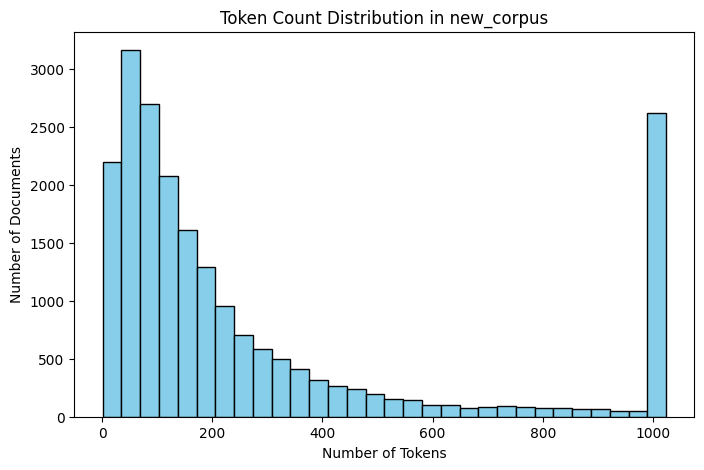

In [11]:
# plot the distribution of the number of tokens
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(num_tokens_list, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Documents')
plt.title('Token Count Distribution in new_corpus')
plt.show()

In [12]:
# Pre-calculate embeddings using Open-AI
from sentence_transformers import SentenceTransformer
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"   # falls back to CPU
embedding_model = SentenceTransformer(EMBEDDING_MODEL, device=device, trust_remote_code=True)  # some remote models need trust_remote_code
docs_embeddings = embedding_model.encode(new_corpus, show_progress_bar=True)

Batches:   0%|          | 0/658 [00:00<?, ?it/s]

In [84]:
flag = "truncated" if TRUNCATE else "chunked"
embeddings_saved_path = f'docs_embeddings_KaLM_{flag}.npy'

In [ ]:
# import numpy as np

# np.save(embeddings_saved_path, docs_embeddings)  # save embeddings for future use

## Load the Embeddings

In [85]:
embeddings = np.load(embeddings_saved_path)  # load embeddings for future use
print(f'Loaded embedding path: {embeddings_saved_path} with shape {embeddings.shape}')

Loaded embedding path: docs_embeddings_KaLM_truncated.npy with shape (18837, 896)


In [69]:
type(docs_embeddings)

numpy.ndarray

In [70]:
# preventing stochastic behaviour for reproducibility
from umap import UMAP
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# # controlling the number of topics
from hdbscan import HDBSCAN
# number_of_clusters = 20
# min_cluster_size = int(len(new_corpus) / number_of_clusters)
hdbscan_model = HDBSCAN(min_cluster_size=40,  metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# improve default representation
from sklearn.feature_extraction.text import CountVectorizer
vectorizer_model = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1, 2))

# additional representations
import openai
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech
keybert_model = KeyBERTInspired() # KeyBERT
# pos_model = PartOfSpeech("en_core_web_sm") # Part-of-Speech
mmr_model = MaximalMarginalRelevance(diversity=0.3) # MMR
nr_repr_docs = 20 # Number of representative documents per topic

client = openai.OpenAI(api_key=api_key)
openai_model = OpenAI(
                client, 
                model="gpt-3.5-turbo", 
                exponential_backoff=True, 
                chat=True, 
                prompt=prompt,
                nr_repr_docs=nr_repr_docs
            )

openai_model_with_description = OpenAI(
                client,
                model="gpt-3.5-turbo",
                exponential_backoff=True,
                chat=True,
                prompt=prompt_topic_desc,
                nr_repr_docs=nr_repr_docs
            )

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "OpenAI-Desc": openai_model_with_description,
    "MMR": mmr_model,
    # "POS": pos_model
}

### TRAINING
from bertopic import BERTopic
topic_model = BERTopic(
        # Pipeline models
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        # Hyperparameters
        top_n_words=10,
        nr_topics=21, # 21 including outlier topic -1
        verbose=True
)

topics, probs = topic_model.fit_transform(new_corpus, docs_embeddings)

2026-02-02 23:33:38,199 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-02 23:33:47,633 - BERTopic - Dimensionality - Completed ✓
2026-02-02 23:33:47,635 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-02 23:33:53,855 - BERTopic - Cluster - Completed ✓
2026-02-02 23:33:53,855 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-02-02 23:33:56,834 - BERTopic - Representation - Completed ✓
2026-02-02 23:33:56,836 - BERTopic - Topic reduction - Reducing number of topics
2026-02-02 23:33:56,850 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 21/21 [00:23<00:00,  1.11s/it]
2026-02-02 23:37:10,322 - BERTopic - Representation - Completed ✓
2026-02-02 23:37:10,328 - BERTopic - Topic reduction - Reduced number of topics from 60 to 21


In [71]:
for topic_idx in topic_model.get_topics().keys():
    data = topic_model.get_topic(topic_idx, full=True)
    print(data["OpenAI"][0])
    print(data["OpenAI-Desc"][0])
    print("------")

('Christian doctrinal discussions', 1)
('Christian theology and doctrine scrutiny', 1)
------
('Vehicle Maintenance and Accessories', 1)
('Motor vehicles enthusiasts discuss maintenance, performance upgrades, and experiences with motorcycles, cars, and specific models like the Guzzi 850-T and Dodge Shadow ES. Discussions include tire selection, engine repairs, and opinions on different manufacturers.', 1)
------
('Image Processing Software Landscape', 1)
('Image Processing and Visualization Tools: Covers various platforms like Windows, DOS, OS/2, X Windows, offering software for JPEG conversion, image viewing, and data visualization. Includes free and commercial options, with focus on compatibility and performance.', 1)
------
('NHL Playoff Results Analysis', 1)
('NHL playoff results and analysis from the 1993 season, including game summaries, team standings, player evaluations, and discussions on the potential impact of top Finnish and Swedish players in the NHL league.', 1)
------
('

In [72]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,OpenAI,OpenAI-Desc,MMR,Representative_Docs
0,-1,3828,-1_ax_ax ax_god_dos,"[ax, ax ax, god, dos, people, like, don, just,...","[god, jesus, bible, christ, church, wrong, rel...",[Christian doctrinal discussions],[Christian theology and doctrine scrutiny],"[ax ax, god, jesus, time, use, 00, church, chr...",[\n\nThe Bible does tell us that governments a...
1,0,3170,0_car_bike_just_edu,"[car, bike, just, edu, like, com, don, cars, e...","[tires, tire, motorcycle, honda, driving, cars...",[Vehicle Maintenance and Accessories],[Motor vehicles enthusiasts discuss maintenanc...,"[bike, cars, engine, ride, miles, oil, bmw, ro...","[Hi, maybe someone can help me here...\nI am l..."
2,1,2293,1_file_image_windows_edu,"[file, image, windows, edu, jpeg, window, grap...","[jpeg, image, images, graphics, gif, software,...",[Image Processing Software Landscape],[Image Processing and Visualization Tools: Cov...,"[image, jpeg, window, graphics, files, ftp, co...",[m)\n and X11 pixmap (xpm) formats. If the i...
3,2,1970,2_game_team_games_year,"[game, team, games, year, season, hockey, play...","[hockey, puck, playoffs, rangers, espn, power ...",[NHL Playoff Results Analysis],[NHL playoff results and analysis from the 199...,"[team, games, season, hockey, players, league,...","[\n\n""Deeply rooted rivalry?"" Ahem, Jokerit ha..."
4,3,1714,3_drive_scsi_card_use,"[drive, scsi, card, use, drives, disk, control...","[scsi, hard disk, disk, drives, pc, bios, hard...",[SCSI interface speeds and usage],[A comprehensive overview of SCSI technology a...,"[scsi, card, drives, disk, controller, monitor...",[david@c-cat.UUCP (Dave) write:\nwe are talkin...
5,4,1097,4_gun_people_guns_fbi,"[gun, people, guns, fbi, batf, koresh, firearm...","[gun control, second amendment, guns, firearms...",[Firearms Politics and Legislation],[Debate on gun control and government interven...,"[gun, guns, fbi, batf, firearms, amendment, gu...","[: > Last year the US suffered almost 10,000 w..."
6,5,1017,5_armenian_armenians_israel_turkish,"[armenian, armenians, israel, turkish, people,...","[armenians, genocide, armenian, armenia, turks...",[Armenian-Turkish Genocide and Collaboration],[Historical controversy surrounding Armenian-T...,"[armenian, armenians, israel, jews, armenia, a...",[\n\n\nDon't be so vague. Let us reexamine it ...
7,6,962,6_space_nasa_launch_earth,"[space, nasa, launch, earth, orbit, shuttle, m...","[spacecraft, nasa, sci space, satellites, spac...",[Solar System Space Exploration],[Space Exploration and Planetary Missions],"[space, nasa, orbit, shuttle, mission, spacecr...",[ (SSTO) PROGRAM\n\n SDI's SSRT (Single Sta...
8,7,888,7_key_encryption_clipper_chip,"[key, encryption, clipper, chip, keys, privacy...","[clipper chip, cryptography, encryption, ciphe...",[Clipper Chip encryption technology],[Overview of the Clipper Chip initiative combi...,"[key, encryption, clipper, privacy, secure, cl...",[Note: This file will also be available via a...
9,8,880,8_god_believe_people_faith,"[god, believe, people, faith, life, religion, ...","[theism, atheist, atheism, atheists, religion,...",[Religious Belief and Coexistence],"[The complex relationship between faith, belie...","[god, religion, atheists, jesus, atheism, beli...",[Archive-name: atheism/introduction\nAlt-athei...


### Getting the Document Info


In [73]:
# # Pre-calculate embeddings of the cropped documents
# from sentence_transformers import SentenceTransformer
# embedding_model = SentenceTransformer(EMBEDDING_MODEL)
# docs_embeddings = embedding_model.encode(new_corpus, show_progress_bar=True)

In [74]:
docs_embeddings.shape

(21031, 896)

In [75]:
# let's also reduce the dimension of the embeddings for storage efficiency
from umap import UMAP
umap_reducer = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
reduced_embeddings = umap_reducer.fit_transform(docs_embeddings)
print(reduced_embeddings.shape)

reduced_centroids = umap_reducer.fit_transform(topic_model.topic_embeddings_)
print(reduced_centroids.shape)

(21031, 5)
(21, 5)


In [76]:
print(type(topic_model.topic_embeddings_))
print(type(reduced_centroids))
print(topic_model.topic_embeddings_.shape)
print(reduced_centroids.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(21, 896)
(21, 5)


In [77]:
# Get document info as DataFrame
doc_info = topic_model.get_document_info(new_corpus)

# Filter out outliers (Topic == -1)
mask = doc_info["Topic"] != -1
filtered_doc_info = doc_info[mask].reset_index(drop=True)
filtered_embeddings = [docs_embeddings[i] for i, keep in enumerate(mask) if keep]
filtered_doc_info["Embedding"] = filtered_embeddings

filtered_recuded_embeddings = [reduced_embeddings[i] for i, keep in enumerate(mask) if keep]
filtered_doc_info["Reduced_Embedding"] = filtered_recuded_embeddings

# Add topic centroid embedding for each document
topic_centroids = topic_model.topic_embeddings_
filtered_doc_info["Topic_Centroid_Embedding"] = filtered_doc_info["Topic"].apply(lambda t: topic_centroids[t])

# Add reduced topic centroid embedding for each document
filtered_doc_info["Reduced_Centroid_Embedding"] = filtered_doc_info["Topic"].apply(lambda t: reduced_centroids[t])

# (Optional) Add OpenAI labels if needed
openai_labels = []
openai_descs = []
for topic in filtered_doc_info["Topic"]:
    topic_data = topic_model.get_topic(topic, full=True)
    openai_label = topic_data["OpenAI"][0] if topic_data and "OpenAI" in topic_data else None
    openai_desc = topic_data["OpenAI-Desc"][0] if topic_data and "OpenAI-Desc" in topic_data else None
    openai_labels.append(openai_label[0])
    openai_descs.append(openai_desc[0])
filtered_doc_info["OpenAI"] = openai_labels
filtered_doc_info["OpenAI-Desc"] = openai_descs


# Select columns as needed
df = filtered_doc_info[["Document", 
                        "Topic", 
                        "OpenAI", 
                        "OpenAI-Desc", 
                        "Embedding", 
                        "Reduced_Embedding", 
                        "Topic_Centroid_Embedding", 
                        "Reduced_Centroid_Embedding", 
                        "Representative_Docs"]]
df.head()

,Document,Topic,OpenAI,OpenAI-Desc,Embedding,Reduced_Embedding,Topic_Centroid_Embedding,Reduced_Centroid_Embedding,Representative_Docs
0,\n\nI am sure some bashers of Pens fans are pr...,2,NHL Playoff Results Analysis,NHL playoff results and analysis from the 1993...,"[-0.041256506, -0.030980663, -0.012389117, 0.0...","[-0.55464596, 10.760173, 6.431778, 0.047383815...","[0.017802946427508026, -0.0005888100136745667,...","[11.601621, 4.907605, 4.7942142, 2.2629895, 4....","[\n\n""Deeply rooted rivalry?"" Ahem, Jokerit ha..."
1,My brother is in the market for a high-perform...,3,SCSI interface speeds and usage,A comprehensive overview of SCSI technology an...,"[0.056773093, -0.06235064, 0.005010536, -0.012...","[0.33984244, -1.4724054, 5.2142153, 1.9155059,...","[-0.004086118191480637, -0.018328029662370682,...","[11.387662, 3.5464118, 4.6932178, 1.8151643, 4...",[david@c-cat.UUCP (Dave) write:\nwe are talkin...
2,\n\n\n\n\tFinally you said what you dream abou...,5,Armenian-Turkish Genocide and Collaboration,Historical controversy surrounding Armenian-Tu...,"[-0.02295096, 0.06338407, 0.06358226, 0.008145...","[-0.08756317, 7.659003, 4.584509, 9.270752, 4....","[-0.021336319448838965, 0.01958836155961401, 0...","[12.265164, 3.7774923, 4.754558, 1.2022749, 4....",[\n\n\nDon't be so vague. Let us reexamine it ...
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3,SCSI interface speeds and usage,A comprehensive overview of SCSI technology an...,"[0.016601406, 0.014283727, -0.042317722, 0.002...","[-0.62823653, -1.4924241, 5.0849347, 1.5718416...","[-0.004086118191480637, -0.018328029662370682,...","[11.387662, 3.5464118, 4.6932178, 1.8151643, 4...",[david@c-cat.UUCP (Dave) write:\nwe are talkin...
4,1) I have an old Jasmine drive which I cann...,3,SCSI interface speeds and usage,A comprehensive overview of SCSI technology an...,"[0.00465845, -0.055724464, 0.0014464449, 0.034...","[-0.5825682, -1.0261642, 5.2533092, 1.5173061,...","[-0.004086118191480637, -0.018328029662370682,...","[11.387662, 3.5464118, 4.6932178, 1.8151643, 4...",[david@c-cat.UUCP (Dave) write:\nwe are talkin...


In [78]:
df['Reduced_Centroid_Embedding'][0]

array([11.601621 ,  4.907605 ,  4.7942142,  2.2629895,  4.8199854],
      dtype=float32)

## Now convet the topics from the BertTopic to **Topic Class**

### Topic Class


In [79]:
import numpy as np
from typing import List, Optional, Any

class Topic:
    def __init__(
        self,
        document_embeddings_hd: np.ndarray,
        document_embeddings_ld: Optional[np.ndarray] = None,
        centroid_hd: Optional[np.ndarray] = None,
        centroid_ld: Optional[np.ndarray] = None,
        documents: Optional[List[str]] = None,
        topic_name: Optional[str] = None,
        topic_desc: Optional[str] = None, 
        representative_docs: Optional[List[str]] = None

    ):
        assert isinstance(document_embeddings_hd, np.ndarray), "document_embeddings_hd must be a numpy array"
        if centroid_hd is not None:
            assert isinstance(centroid_hd, np.ndarray), "centroid_hd must be a numpy array"
        if documents is not None:
            assert isinstance(documents, list), "documents must be a list of strings"
        self.document_embeddings_hd = document_embeddings_hd
        self.centroid_hd = centroid_hd
        self.documents = documents or []
        self.topic_name = topic_name
        self.topic_desc = topic_desc
        if document_embeddings_ld is not None:
            assert isinstance(document_embeddings_ld, np.ndarray), "document_embeddings_ld must be a numpy array"
            self.document_embeddings_ld = document_embeddings_ld
        else:
            self.document_embeddings_ld = None
        if centroid_ld is not None:
            assert isinstance(centroid_ld, np.ndarray), "centroid_ld must be a numpy array"
            self.centroid_ld = centroid_ld
        else:
            self.centroid_ld = None
        self.representative_docs = representative_docs or []

In [80]:
topic_objs = []

for topic_idx in df["Topic"].unique():
    topic_rows = df[df["Topic"] == topic_idx]
    centroid = topic_rows["Topic_Centroid_Embedding"].iloc[0]
    openai = topic_rows["OpenAI"].iloc[0]
    openai_desc = topic_rows["OpenAI-Desc"].iloc[0]
    documents = topic_rows["Document"].tolist()
    doc_embeddings = np.stack(topic_rows["Embedding"].values)  # shape: (n_docs, embedding_dim)
    reduced_doc_embeddings = np.stack(topic_rows["Reduced_Embedding"].values)  # shape: (n_docs, reduced_embedding_dim)
    centroid_ld = topic_rows["Reduced_Centroid_Embedding"].iloc[0]
    representative_docs = topic_rows["Representative_Docs"].iloc[0]
    topic_obj = Topic(
        document_embeddings_hd=doc_embeddings,
        centroid_hd=centroid,
        documents=documents,
        topic_name=openai,
        topic_desc=openai_desc,
        document_embeddings_ld=reduced_doc_embeddings, 
        centroid_ld=centroid_ld,
        representative_docs=representative_docs
    )
    topic_objs.append(topic_obj)

In [81]:
### sanity check for the topic objects

for topic in topic_objs:
    assert isinstance(topic, Topic), "Each item in topic_objs must be an instance of Topic"
    assert topic.document_embeddings_hd is not None, "document_embeddings_hd should not be None"
    assert topic.document_embeddings_ld is not None, "document_embeddings_ld should not be None"
    assert topic.centroid_hd is not None, "centroid_hd should not be None"
    assert isinstance(topic.documents, list), "documents should be a list"
    assert isinstance(topic.topic_name, str), "topic_name should be a string"
    assert isinstance(topic.topic_desc, str), "topic_desc should be a string"
    assert topic.document_embeddings_hd.shape[0] == len(topic.documents), "Mismatch between number of document embeddings and documents"
    assert topic.document_embeddings_ld.shape[0] == len(topic.documents), "Mismatch between number of reduced document embeddings and documents"
    assert topic.centroid_ld is not None, "centroid_ld should not be None"
    assert isinstance(topic.representative_docs, list), "representative_docs should be a list"
print("All topic objects passed the sanity checks.")

All topic objects passed the sanity checks.


In [82]:
print(flag)

truncated


In [83]:
# save the topic objects using pickle for later use in other notebooks
import pickle
flag = "truncated" if TRUNCATE else "chunked"
path = f"{flag}_docs_topic_objs_KaLM.pkl"
print(path)

with open(path, "wb") as f:
    pickle.dump(topic_objs, f)

truncated_docs_topic_objs_KaLM.pkl


In [ ]:
# load the truncated docs topic objects
import pickle

with open(path, "rb") as f:
    topic_objs = pickle.load(f)

In [ ]:
import pickle

with open(path, "rb") as f:
    topic_objs = pickle.load(f)

# Check the number of topics loaded
print(f"Loaded {len(topic_objs)} topics.")

# Check the first topic's name and number of documents
print(topic_objs[0].topic_name, len(topic_objs[0].documents))

Loaded 20 topics.
Sports Team Evaluations 1851


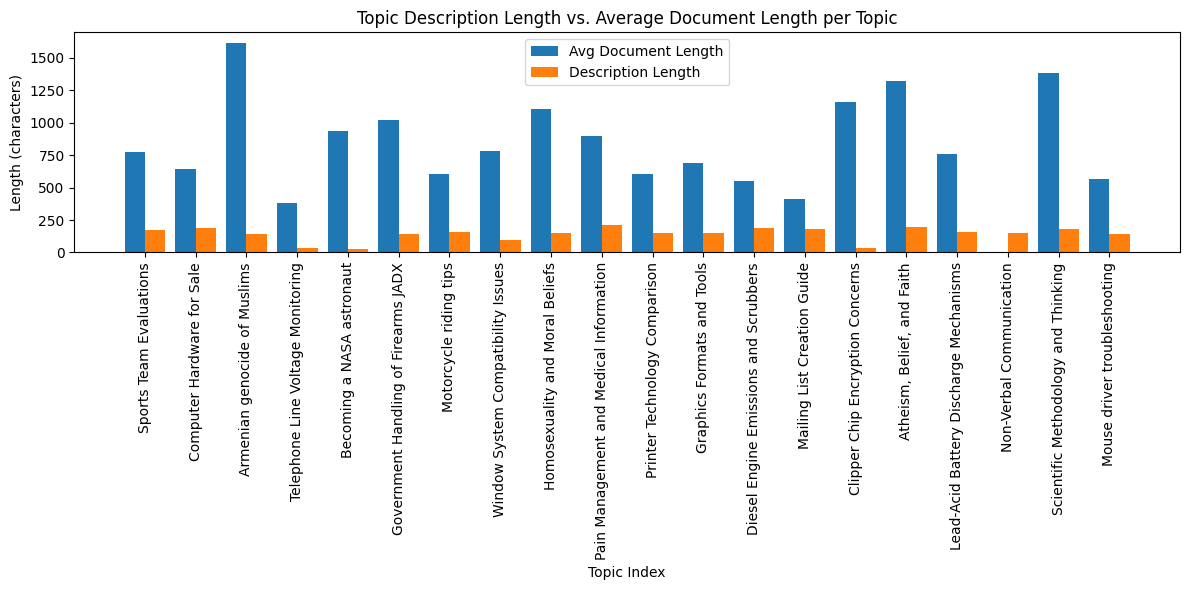

In [29]:
import matplotlib.pyplot as plt
import numpy as np

avg_doc_lengths = []
desc_lengths = []
topic_labels = []

for topic in topic_objs:
    avg_doc_lengths.append(np.mean([len(doc) for doc in topic.documents]))
    desc_lengths.append(len(topic.topic_desc) if topic.topic_desc else 0)
    topic_labels.append(topic.topic_name if topic.topic_name else "")

x = np.arange(len(topic_objs))

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, avg_doc_lengths, width=0.4, label='Avg Document Length')
plt.bar(x + 0.2, desc_lengths, width=0.4, label='Description Length')
plt.xlabel('Topic Index')
plt.ylabel('Length (characters)')
plt.title('Topic Description Length vs. Average Document Length per Topic')
plt.legend()
plt.xticks(x, topic_labels, rotation=90)
plt.tight_layout()
plt.show()

____


NOTE: Here, the prompt in the above function was from the example given by the BerTopic github. 
- Say we use the a different promt, then can we create different output? 
- TODO: [] CHECK THIS. 

In [30]:
# freq = topic_model.get_topic_info(); freq.head(5)

____

In [31]:
# import pandas as pd
# import numpy as np

# # Dummy data
# docs = [
#     "Document about sports.",
#     "Politics and government news.",
#     "Technology advances in AI.",
#     "Health and wellness tips.",
#     "Travel destinations for 2025."
# ]

# n_clusters = 3
# np.random.seed(42)
# random_labels = np.random.randint(1, n_clusters + 1, size=len(docs))

# # Create DataFrame
# df = pd.DataFrame({
#     "Document": docs,
#     "RandomCluster": random_labels
# })

# print(df)

In [32]:
# import pandas as pd
# import numpy as np

# # Dummy data
# docs = [
#     "Document about sports.",
#     "Politics and government news.",
#     "Technology advances in AI.",
#     "Health and wellness tips.",
#     "Travel destinations for 2025."
# ]

# N = 5  # Number of random clusterings
# C = 3  # Number of clusters

# np.random.seed(42)
# random_labels_matrix = np.random.randint(1, C + 1, size=(len(docs), N))

# # Create DataFrame
# df = pd.DataFrame({"Document": docs})
# for i in range(N):
#     df[f"RandomCluster_{i+1}"] = random_labels_matrix[:, i]

# print(df)